In [3]:
import cv2
import matplotlib.pyplot as plt
from doctr.models import ocr_predictor

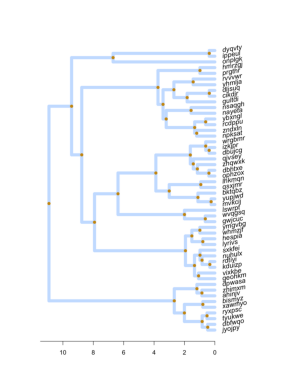

In [7]:
img_path = "dev/_datasets/Tree_PNG_50tips_NOISE_1/images/Tree_50_6.png"
img_rgb = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.axis("off")
plt.show()

In [5]:
predictor = ocr_predictor(pretrained=True)

  0%|          | 0/65814772 [00:00<?, ?it/s]

  0%|          | 0/63303144 [00:00<?, ?it/s]

In [9]:
result = predictor([img_rgb])

In [11]:
text_entries = []
for page in result.pages:
    for block in page.blocks:
        for line in block.lines:
            for word in line.words:
                bbox = word.geometry
                text = word.value
                score = word.confidence
                text_entries.append({"bbox": bbox, "text": text, "score": score})

print(f"Nombre de textes détectés : {len(text_entries)}")

Nombre de textes détectés : 56


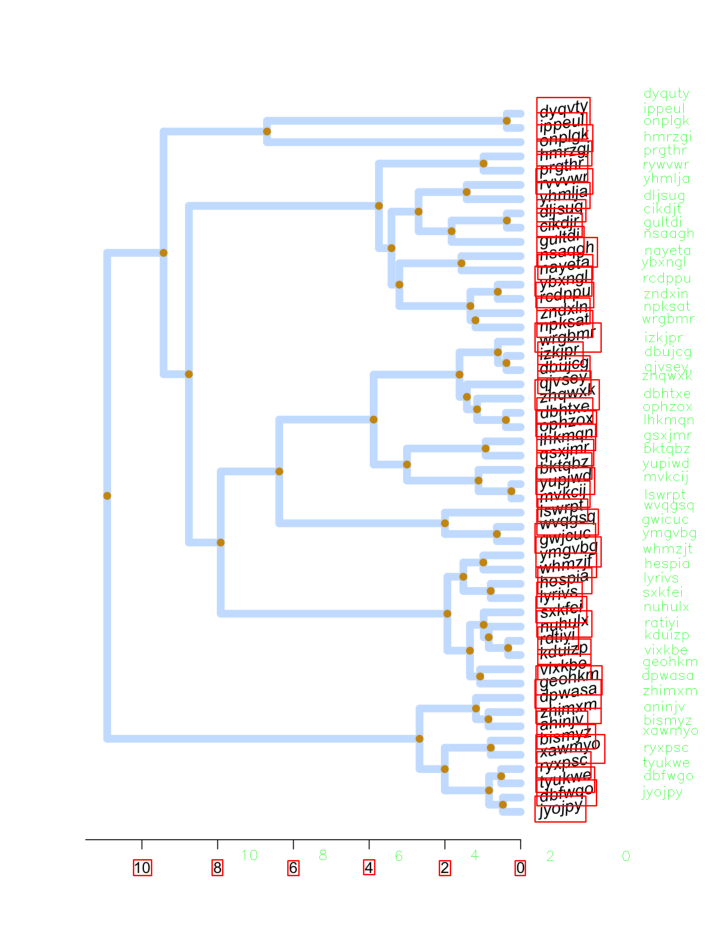

In [27]:
h, w = img_rgb.shape[:2]

img_show = img_rgb.copy()

for entry in text_entries:
    (x1, y1), (x2, y2) = entry["bbox"]

    x1 = int(x1 * w)
    y1 = int(y1 * h)
    x2 = int(x2 * w)
    y2 = int(y2 * h)

    cv2.rectangle(img_show, (x1, y1), (x2, y2), (255,0,0), 2)
    cv2.putText(img_show, entry["text"], (x1 + 230, y1), cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,0), 1)

plt.figure(figsize=(12,12))
plt.imshow(img_show)
plt.axis("off")
plt.show()

In [19]:
filtered_text_boxes = [
    entry for entry in text_entries
    if not any(char.isdigit() for char in entry['text'])
]

for i, entry in enumerate(filtered_text_boxes[:20], 1):
    print(f"{i}: text='{entry['text']}', score={entry['score']:.2f}, bbox={entry['bbox']}")

1: text='dyquty', score=0.98, bbox=((np.float64(0.7604166666666667), np.float64(0.0947265625)), (np.float64(0.8372395833333333), np.float64(0.1240234375)))
2: text='ippeul', score=0.91, bbox=((np.float64(0.7604166666666667), np.float64(0.111328125)), (np.float64(0.83203125), np.float64(0.1396484375)))
3: text='onplgk', score=0.94, bbox=((np.float64(0.7604166666666667), np.float64(0.1240234375)), (np.float64(0.8411458333333333), np.float64(0.1533203125)))
4: text='hmrzgi', score=0.70, bbox=((np.float64(0.7604166666666667), np.float64(0.1416015625)), (np.float64(0.83984375), np.float64(0.1689453125)))
5: text='prgthr', score=0.97, bbox=((np.float64(0.7604166666666667), np.float64(0.15625)), (np.float64(0.8333333333333333), np.float64(0.185546875)))
6: text='rywvwr', score=0.52, bbox=((np.float64(0.7591145833333333), np.float64(0.171875)), (np.float64(0.8411458333333333), np.float64(0.19921875)))
7: text='yhmlja', score=0.64, bbox=((np.float64(0.7604166666666667), np.float64(0.1865234375)